# 02 - Limpieza y calidad de datos

Este notebook tiene como objetivo realizar la limpieza inicial de la base de ventas y construir las variables necesarias para el análisis exploratorio completo.

A diferencia del notebook anterior, aquí sí se transforma la base original para dejarla en un formato analítico.

Las tareas principales son:

- Cargar la base original desde `data/raw`.
- Convertir la fecha desde serial de Excel a fecha real.
- Convertir columnas numéricas con formato decimal.
- Normalizar variables categóricas.
- Crear la variable `VENTA_NETA`.
- Crear variables temporales para el análisis.
- Crear variables de promoción y descuento.
- Crear identificador único de ticket.
- Marcar registros con posibles problemas de calidad.
- Guardar una versión limpia en `data/processed`.

En este punto no se eliminan registros de forma agresiva. Los casos especiales se conservan y se marcan con banderas para analizarlos posteriormente.

In [1]:
# ===============================
# Imports principales
# ===============================

from pathlib import Path
import sys
import os

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_theme(style="whitegrid", context="notebook")

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [2]:
# ===============================
# Rutas del proyecto
# ===============================

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"

REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
TABLES_DIR = REPORTS_DIR / "tables"

RAW_FILE = RAW_DIR / "Ventas_1.csv"

INTERIM_FILE = INTERIM_DIR / "ventas_limpieza_inicial.parquet"
PROCESSED_FILE = PROCESSED_DIR / "ventas_eda.parquet"

print("Raíz del proyecto:")
print(PROJECT_ROOT)

print("\nArchivo original:")
print(RAW_FILE)

print("\n¿Existe el archivo?")
print(RAW_FILE.exists())

Raíz del proyecto:
c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica

Archivo original:
c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\data\raw\Ventas_1.csv

¿Existe el archivo?
True


In [3]:
# ===============================
# Carga de la base original
# ===============================

df_raw = pd.read_csv(
    RAW_FILE,
    encoding="utf-8-sig",
    dtype={
        "CATEG": str,
        "PLU_SAP": str,
        "FACTURA": str,
        "PDV": str,
        "OFERTA_ID": str,
        "GRUCOM": str,
        "Estrato": str
    },
    low_memory=False
)

print("Base original cargada correctamente.")
print(f"Filas: {df_raw.shape[0]:,}")
print(f"Columnas: {df_raw.shape[1]:,}")

df_raw.head()

Base original cargada correctamente.
Filas: 409,760
Columnas: 12


,NroReg,FECHA,PDV,Estrato,OFERTA_ID,FACTURA,CATEG,PLU_SAP,CANT,VENTA,DESCUENTO,GRUCOM
0,4,44927,980,4,0,1,04010,1280454,3,298,"0,00",10
1,12,44927,1255,4,0,2,04010,1328730,1,115,"0,00",10
2,24,44927,1255,4,0,3,04010,1036266,3,448,"0,00",10
3,36,44927,1311,6,0,4,08061,1265857,1,82,"0,00",11
4,37,44927,980,4,0,5,04010,1328946,4,519,"0,00",10


In [4]:
# ===============================
# Copia de trabajo
# ===============================

df = df_raw.copy()

print("Copia de trabajo creada.")
print(df.shape)

Copia de trabajo creada.
(409760, 12)


In [5]:
# ===============================
# Resumen inicial de tipos y nulos
# ===============================

resumen_inicial = pd.DataFrame({
    "columna": df.columns,
    "tipo_original": df.dtypes.astype(str).values,
    "nulos": df.isna().sum().values,
    "nulos_pct": (df.isna().mean().values * 100).round(4),
    "unicos": df.nunique(dropna=False).values
})

resumen_inicial

,columna,tipo_original,nulos,nulos_pct,unicos
0,NroReg,int64,0,0.00,409760
1,FECHA,int64,0,0.00,731
2,PDV,str,0,0.00,3
3,Estrato,str,0,0.00,2
4,OFERTA_ID,str,0,0.00,3123
5,FACTURA,str,0,0.00,233889
6,CATEG,str,0,0.00,7
7,PLU_SAP,str,0,0.00,6039
8,CANT,str,180,0.04,242
9,VENTA,int64,0,0.00,4083


In [6]:
# ===============================
# Funciones auxiliares
# ===============================

def limpiar_texto_codigo(serie, zfill=None):
    """
    Limpia columnas de códigos que deben tratarse como texto.
    Elimina espacios, comillas y terminaciones tipo .0.
    Opcionalmente rellena con ceros a la izquierda.
    """
    s = (
        serie.astype("string")
        .str.strip()
        .str.replace('"', "", regex=False)
        .str.replace("'", "", regex=False)
    )
    
    s = s.str.replace(r"\.0$", "", regex=True)
    
    if zfill is not None:
        s = s.mask(s.isna(), pd.NA)
        s = s.apply(lambda x: x.zfill(zfill) if pd.notna(x) else pd.NA)
    
    return s


def convertir_numero(serie):
    """
    Convierte una columna con posibles comas decimales a número.
    Soporta formatos como:
    - 10,5
    - 10.5
    - 1.234,56
    """
    s = (
        serie.astype("string")
        .str.strip()
        .str.replace('"', "", regex=False)
        .str.replace("'", "", regex=False)
    )
    
    # Si tiene punto y coma, asumimos formato latino: 1.234,56
    mask_punto_coma = s.str.contains(r"\.", na=False) & s.str.contains(",", na=False)
    s = s.mask(mask_punto_coma, s[mask_punto_coma].str.replace(".", "", regex=False))
    
    # Reemplazar coma decimal por punto
    s = s.str.replace(",", ".", regex=False)
    
    return pd.to_numeric(s, errors="coerce")


def porcentaje(parte, total):
    """
    Calcula porcentaje evitando división entre cero.
    """
    if total == 0:
        return np.nan
    return parte / total * 100

In [7]:
# ===============================
# Limpieza de variables categóricas
# ===============================

df["PDV"] = limpiar_texto_codigo(df["PDV"])
df["Estrato"] = limpiar_texto_codigo(df["Estrato"])
df["OFERTA_ID"] = limpiar_texto_codigo(df["OFERTA_ID"])
df["FACTURA"] = limpiar_texto_codigo(df["FACTURA"])
df["CATEG"] = limpiar_texto_codigo(df["CATEG"], zfill=5)
df["PLU_SAP"] = limpiar_texto_codigo(df["PLU_SAP"])
df["GRUCOM"] = limpiar_texto_codigo(df["GRUCOM"])

print("Variables categóricas limpiadas.")

df[["PDV", "Estrato", "OFERTA_ID", "FACTURA", "CATEG", "PLU_SAP", "GRUCOM"]].head()

Variables categóricas limpiadas.


,PDV,Estrato,OFERTA_ID,FACTURA,CATEG,PLU_SAP,GRUCOM
0,980,4,0,1,04010,1280454,10
1,1255,4,0,2,04010,1328730,10
2,1255,4,0,3,04010,1036266,10
3,1311,6,0,4,08061,1265857,11
4,980,4,0,5,04010,1328946,10


In [8]:
# ===============================
# Conversión de fecha
# ===============================

df["FECHA_ORIGINAL"] = df["FECHA"]

df["FECHA"] = pd.to_datetime(
    pd.to_numeric(df["FECHA"], errors="coerce"),
    unit="D",
    origin="1899-12-30",
    errors="coerce"
)

print("Conversión de fecha finalizada.")
print("Fecha mínima:", df["FECHA"].min())
print("Fecha máxima:", df["FECHA"].max())
print("Fechas nulas:", df["FECHA"].isna().sum())
print("Días únicos:", df["FECHA"].nunique())

Conversión de fecha finalizada.
Fecha mínima: 2023-01-01 00:00:00
Fecha máxima: 2024-12-31 00:00:00
Fechas nulas: 0
Días únicos: 731


In [9]:
# ===============================
# Conversión de variables numéricas
# ===============================

df["NroReg"] = pd.to_numeric(df["NroReg"], errors="coerce")
df["CANT"] = convertir_numero(df["CANT"])
df["VENTA"] = convertir_numero(df["VENTA"])
df["DESCUENTO"] = convertir_numero(df["DESCUENTO"])
df["OFERTA_ID_NUM"] = convertir_numero(df["OFERTA_ID"])

print("Conversión numérica finalizada.")

df[["NroReg", "CANT", "VENTA", "DESCUENTO", "OFERTA_ID", "OFERTA_ID_NUM"]].head()

Conversión numérica finalizada.


,NroReg,CANT,VENTA,DESCUENTO,OFERTA_ID,OFERTA_ID_NUM
0,4,3.00,298,0.00,0,0
1,12,1.00,115,0.00,0,0
2,24,3.00,448,0.00,0,0
3,36,1.00,82,0.00,0,0
4,37,4.00,519,0.00,0,0


In [11]:
# ===============================
# Variables principales de venta
# ===============================

# Asegurar que las columnas numéricas queden como float normal
df["CANT"] = pd.to_numeric(df["CANT"], errors="coerce").astype(float)
df["VENTA"] = pd.to_numeric(df["VENTA"], errors="coerce").astype(float)
df["DESCUENTO"] = pd.to_numeric(df["DESCUENTO"], errors="coerce").astype(float)

# Venta neta
df["VENTA_NETA"] = df["VENTA"] - df["DESCUENTO"]

# Porcentaje de descuento
df["DESCUENTO_PCT"] = np.nan
mask_venta_positiva = df["VENTA"].notna() & (df["VENTA"] > 0)

df.loc[mask_venta_positiva, "DESCUENTO_PCT"] = (
    df.loc[mask_venta_positiva, "DESCUENTO"] / 
    df.loc[mask_venta_positiva, "VENTA"] * 100
)

# Precio unitario bruto
df["PRECIO_UNITARIO_BRUTO"] = np.nan
mask_cant_positiva = df["CANT"].notna() & (df["CANT"] > 0)

df.loc[mask_cant_positiva, "PRECIO_UNITARIO_BRUTO"] = (
    df.loc[mask_cant_positiva, "VENTA"] / 
    df.loc[mask_cant_positiva, "CANT"]
)

# Precio unitario neto
df["PRECIO_UNITARIO_NETO"] = np.nan

df.loc[mask_cant_positiva, "PRECIO_UNITARIO_NETO"] = (
    df.loc[mask_cant_positiva, "VENTA_NETA"] / 
    df.loc[mask_cant_positiva, "CANT"]
)

print("Variables de venta creadas correctamente.")

df[[
    "CANT", 
    "VENTA", 
    "DESCUENTO", 
    "VENTA_NETA", 
    "DESCUENTO_PCT", 
    "PRECIO_UNITARIO_BRUTO", 
    "PRECIO_UNITARIO_NETO"
]].head()

Variables de venta creadas correctamente.


,CANT,VENTA,DESCUENTO,VENTA_NETA,DESCUENTO_PCT,PRECIO_UNITARIO_BRUTO,PRECIO_UNITARIO_NETO
0,3.00,298.00,0.00,298.00,0.00,99.33,99.33
1,1.00,115.00,0.00,115.00,0.00,115.00,115.00
2,3.00,448.00,0.00,448.00,0.00,149.33,149.33
3,1.00,82.00,0.00,82.00,0.00,82.00,82.00
4,4.00,519.00,0.00,519.00,0.00,129.75,129.75


In [12]:
# ===============================
# Variables de promoción
# ===============================

df["PROMO_OFERTA_FLAG"] = df["OFERTA_ID_NUM"].fillna(0) > 0
df["PROMO_DESCUENTO_FLAG"] = df["DESCUENTO"].fillna(0) > 0

df["PROMO_FLAG"] = df["PROMO_OFERTA_FLAG"] | df["PROMO_DESCUENTO_FLAG"]

df["TIPO_PROMO"] = np.select(
    [
        df["PROMO_OFERTA_FLAG"] & df["PROMO_DESCUENTO_FLAG"],
        df["PROMO_OFERTA_FLAG"] & ~df["PROMO_DESCUENTO_FLAG"],
        ~df["PROMO_OFERTA_FLAG"] & df["PROMO_DESCUENTO_FLAG"]
    ],
    [
        "Oferta y descuento",
        "Solo oferta",
        "Solo descuento"
    ],
    default="Sin promoción"
)

print("Variables de promoción creadas.")

df[["OFERTA_ID", "OFERTA_ID_NUM", "DESCUENTO", "PROMO_FLAG", "TIPO_PROMO"]].head()

Variables de promoción creadas.


,OFERTA_ID,OFERTA_ID_NUM,DESCUENTO,PROMO_FLAG,TIPO_PROMO
0,0,0,0.00,False,Sin promoción
1,0,0,0.00,False,Sin promoción
2,0,0,0.00,False,Sin promoción
3,0,0,0.00,False,Sin promoción
4,0,0,0.00,False,Sin promoción


In [13]:
# ===============================
# Variables temporales
# ===============================

df["ANIO"] = df["FECHA"].dt.year
df["MES"] = df["FECHA"].dt.month
df["DIA"] = df["FECHA"].dt.day
df["DIA_SEMANA_NUM"] = df["FECHA"].dt.dayofweek
df["DIA_SEMANA"] = df["FECHA"].dt.day_name()
df["SEMANA_ANIO"] = df["FECHA"].dt.isocalendar().week.astype("Int64")
df["TRIMESTRE"] = df["FECHA"].dt.quarter
df["FIN_SEMANA"] = df["DIA_SEMANA_NUM"].isin([5, 6])
df["FIN_MES"] = df["FECHA"].dt.is_month_end
df["INICIO_MES"] = df["FECHA"].dt.is_month_start
df["QUINCENA"] = np.where(df["DIA"] <= 15, 1, 2)

# Nombre de mes en español para gráficos
mapa_meses = {
    1: "Enero",
    2: "Febrero",
    3: "Marzo",
    4: "Abril",
    5: "Mayo",
    6: "Junio",
    7: "Julio",
    8: "Agosto",
    9: "Septiembre",
    10: "Octubre",
    11: "Noviembre",
    12: "Diciembre"
}

mapa_dias = {
    0: "Lunes",
    1: "Martes",
    2: "Miércoles",
    3: "Jueves",
    4: "Viernes",
    5: "Sábado",
    6: "Domingo"
}

df["MES_NOMBRE"] = df["MES"].map(mapa_meses)
df["DIA_SEMANA_NOMBRE"] = df["DIA_SEMANA_NUM"].map(mapa_dias)

print("Variables temporales creadas.")

df[[
    "FECHA", 
    "ANIO", 
    "MES", 
    "MES_NOMBRE",
    "DIA", 
    "DIA_SEMANA_NUM",
    "DIA_SEMANA_NOMBRE",
    "SEMANA_ANIO",
    "TRIMESTRE",
    "FIN_SEMANA",
    "FIN_MES",
    "QUINCENA"
]].head()

Variables temporales creadas.


,FECHA,ANIO,MES,MES_NOMBRE,DIA,DIA_SEMANA_NUM,DIA_SEMANA_NOMBRE,SEMANA_ANIO,TRIMESTRE,FIN_SEMANA,FIN_MES,QUINCENA
0,2023-01-01,2023,1,Enero,1,6,Domingo,52,1,True,False,1
1,2023-01-01,2023,1,Enero,1,6,Domingo,52,1,True,False,1
2,2023-01-01,2023,1,Enero,1,6,Domingo,52,1,True,False,1
3,2023-01-01,2023,1,Enero,1,6,Domingo,52,1,True,False,1
4,2023-01-01,2023,1,Enero,1,6,Domingo,52,1,True,False,1


In [14]:
# ===============================
# Identificador único de ticket
# ===============================

df["TICKET_ID"] = (
    df["FECHA"].dt.strftime("%Y-%m-%d") + "_" +
    df["PDV"].astype(str) + "_" +
    df["FACTURA"].astype(str)
)

print(f"Facturas únicas globales: {df['FACTURA'].nunique():,}")
print(f"Tickets únicos FECHA + PDV + FACTURA: {df['TICKET_ID'].nunique():,}")

df[["FECHA", "PDV", "FACTURA", "TICKET_ID"]].head()

Facturas únicas globales: 233,889
Tickets únicos FECHA + PDV + FACTURA: 276,989


,FECHA,PDV,FACTURA,TICKET_ID
0,2023-01-01,980,1,2023-01-01_980_1
1,2023-01-01,1255,2,2023-01-01_1255_2
2,2023-01-01,1255,3,2023-01-01_1255_3
3,2023-01-01,1311,4,2023-01-01_1311_4
4,2023-01-01,980,5,2023-01-01_980_5


In [15]:
# ===============================
# Banderas de calidad
# ===============================

df["FLAG_FECHA_NULA"] = df["FECHA"].isna()

df["FLAG_CANT_NULA"] = df["CANT"].isna()
df["FLAG_CANT_CERO"] = df["CANT"] == 0
df["FLAG_CANT_NEGATIVA"] = df["CANT"] < 0

df["FLAG_VENTA_NULA"] = df["VENTA"].isna()
df["FLAG_VENTA_CERO"] = df["VENTA"] == 0
df["FLAG_VENTA_NEGATIVA"] = df["VENTA"] < 0

df["FLAG_DESCUENTO_NULO"] = df["DESCUENTO"].isna()
df["FLAG_DESCUENTO_CERO"] = df["DESCUENTO"] == 0
df["FLAG_DESCUENTO_NEGATIVO"] = df["DESCUENTO"] < 0
df["FLAG_DESCUENTO_MAYOR_VENTA"] = df["DESCUENTO"] > df["VENTA"]

df["FLAG_VENTA_NETA_NULA"] = df["VENTA_NETA"].isna()
df["FLAG_VENTA_NETA_CERO"] = df["VENTA_NETA"] == 0
df["FLAG_VENTA_NETA_NEGATIVA"] = df["VENTA_NETA"] < 0

df["FLAG_PRECIO_UNITARIO_NETO_NULO"] = df["PRECIO_UNITARIO_NETO"].isna()
df["FLAG_PRECIO_UNITARIO_NETO_NEGATIVO"] = df["PRECIO_UNITARIO_NETO"] < 0

flags_calidad = [
    "FLAG_FECHA_NULA",
    "FLAG_CANT_NULA",
    "FLAG_CANT_CERO",
    "FLAG_CANT_NEGATIVA",
    "FLAG_VENTA_NULA",
    "FLAG_VENTA_CERO",
    "FLAG_VENTA_NEGATIVA",
    "FLAG_DESCUENTO_NULO",
    "FLAG_DESCUENTO_NEGATIVO",
    "FLAG_DESCUENTO_MAYOR_VENTA",
    "FLAG_VENTA_NETA_NULA",
    "FLAG_VENTA_NETA_CERO",
    "FLAG_VENTA_NETA_NEGATIVA",
    "FLAG_PRECIO_UNITARIO_NETO_NULO",
    "FLAG_PRECIO_UNITARIO_NETO_NEGATIVO"
]

df["REGISTRO_ESPECIAL"] = df[flags_calidad].any(axis=1)

print("Banderas de calidad creadas.")
print(f"Registros especiales: {df['REGISTRO_ESPECIAL'].sum():,}")
print(f"Porcentaje registros especiales: {df['REGISTRO_ESPECIAL'].mean() * 100:.2f}%")

Banderas de calidad creadas.
Registros especiales: 13,497
Porcentaje registros especiales: 3.29%


In [16]:
# ===============================
# Registro válido básico
# ===============================

df["REGISTRO_VALIDO_BASICO"] = (
    df["FECHA"].notna() &
    df["CANT"].notna() &
    df["VENTA"].notna() &
    df["DESCUENTO"].notna() &
    (df["CANT"] > 0) &
    (df["VENTA"] > 0) &
    (df["DESCUENTO"] >= 0) &
    (df["DESCUENTO"] <= df["VENTA"]) &
    (df["VENTA_NETA"] >= 0)
)

print(f"Registros válidos básicos: {df['REGISTRO_VALIDO_BASICO'].sum():,}")
print(f"Porcentaje válidos básicos: {df['REGISTRO_VALIDO_BASICO'].mean() * 100:.2f}%")

print(f"\nRegistros no válidos básicos: {(~df['REGISTRO_VALIDO_BASICO']).sum():,}")
print(f"Porcentaje no válidos básicos: {(~df['REGISTRO_VALIDO_BASICO']).mean() * 100:.2f}%")

Registros válidos básicos: 398,537
Porcentaje válidos básicos: 97.26%

Registros no válidos básicos: 11,223
Porcentaje no válidos básicos: 2.74%


In [17]:
# ===============================
# Resumen de banderas de calidad
# ===============================

resumen_flags = []

for flag in flags_calidad:
    cantidad = df[flag].sum()
    resumen_flags.append({
        "bandera": flag,
        "cantidad": cantidad,
        "porcentaje": cantidad / len(df) * 100
    })

resumen_flags = pd.DataFrame(resumen_flags).sort_values("cantidad", ascending=False)
resumen_flags["porcentaje"] = resumen_flags["porcentaje"].round(4)

resumen_flags

,bandera,cantidad,porcentaje
9,FLAG_DESCUENTO_MAYOR_VENTA,8799,2.15
12,FLAG_VENTA_NETA_NEGATIVA,8799,2.15
14,FLAG_PRECIO_UNITARIO_NETO_NEGATIVO,8553,2.09
11,FLAG_VENTA_NETA_CERO,4521,1.10
5,FLAG_VENTA_CERO,3470,0.85
13,FLAG_PRECIO_UNITARIO_NETO_NULO,2635,0.64
2,FLAG_CANT_CERO,2322,0.57
6,FLAG_VENTA_NEGATIVA,1763,0.43
1,FLAG_CANT_NULA,180,0.04
3,FLAG_CANT_NEGATIVA,133,0.03


In [18]:
# ===============================
# Nulos después de limpieza
# ===============================

resumen_nulos_limpio = (
    df.isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "columna", 0: "nulos"})
)

resumen_nulos_limpio["nulos_pct"] = (
    resumen_nulos_limpio["nulos"] / len(df) * 100
).round(4)

resumen_nulos_limpio = resumen_nulos_limpio.sort_values("nulos", ascending=False)

resumen_nulos_limpio.head(30)

,columna,nulos,nulos_pct
15,DESCUENTO_PCT,5233,1.28
16,PRECIO_UNITARIO_BRUTO,2635,0.64
17,PRECIO_UNITARIO_NETO,2635,0.64
8,CANT,180,0.04
0,NroReg,0,0.00
1,FECHA,0,0.00
5,FACTURA,0,0.00
4,OFERTA_ID,0,0.00
3,Estrato,0,0.00
2,PDV,0,0.00


C:\Users\sergi\AppData\Local\Temp\ipykernel_40848\4132851631.py:8: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<Figure size 1400x600 with 0 Axes>

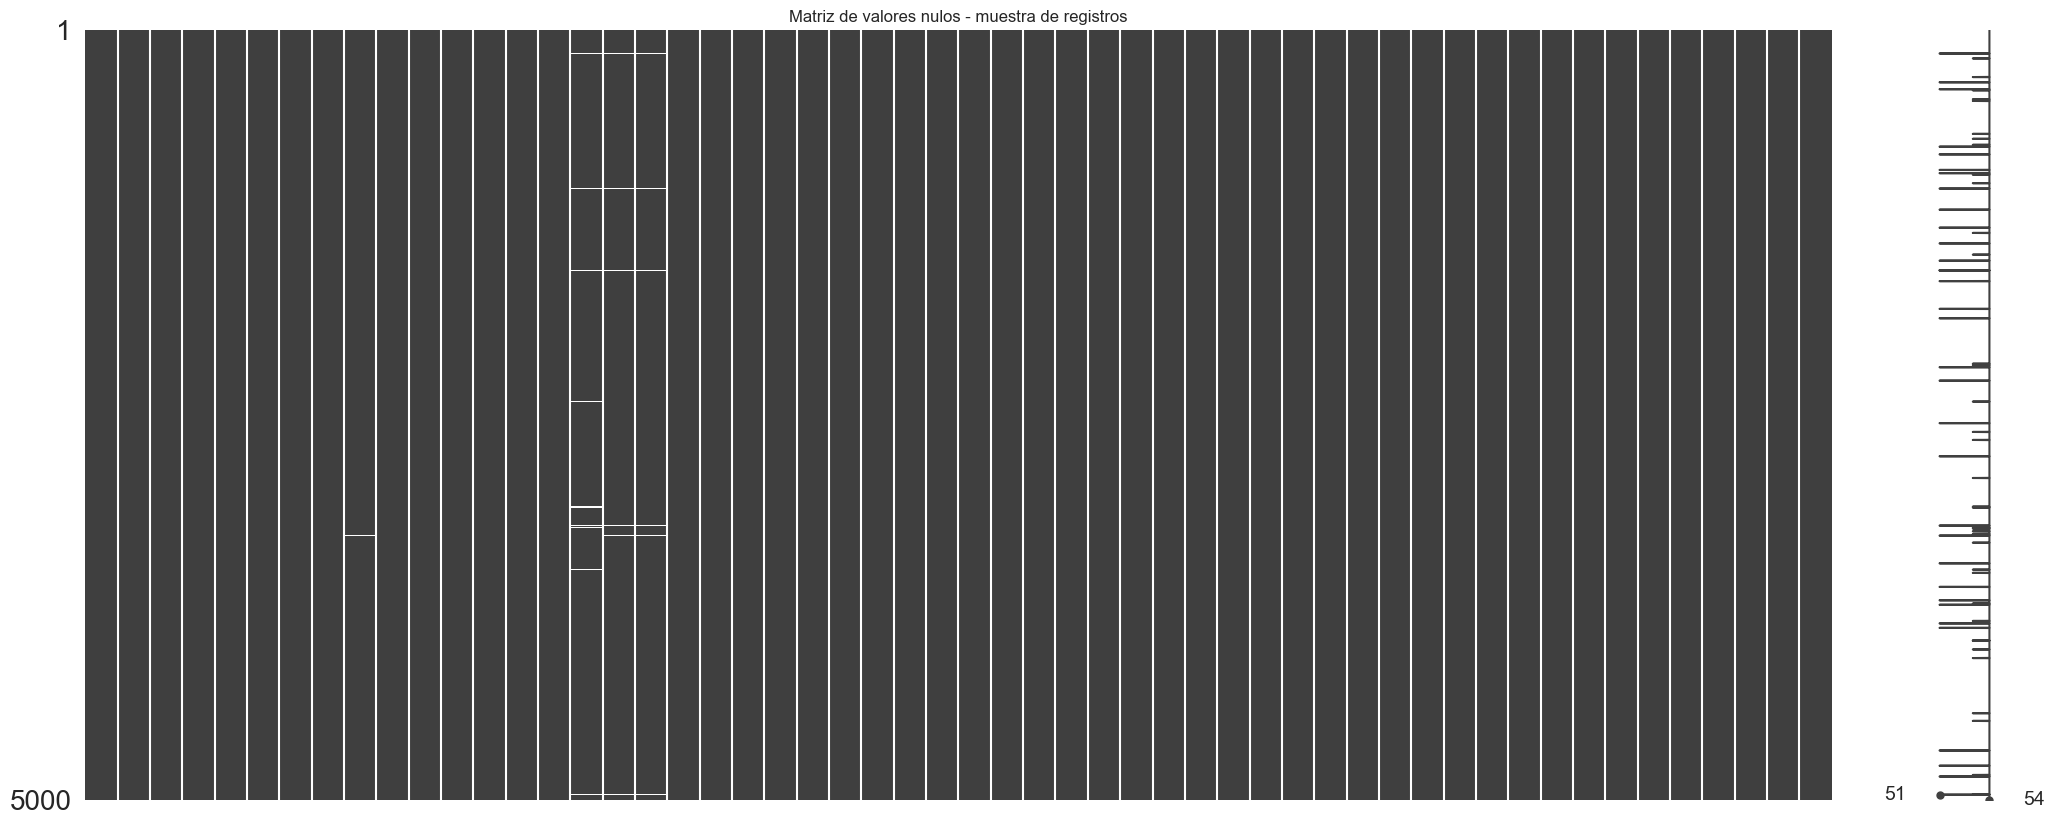

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\calidad_datos\matriz_nulos_muestra.png


In [19]:
# ===============================
# Visualización de valores nulos
# ===============================

plt.figure(figsize=(14, 6))
msno.matrix(df.sample(min(5000, len(df)), random_state=42))
plt.title("Matriz de valores nulos - muestra de registros")
plt.tight_layout()

output_fig = FIGURES_DIR / "calidad_datos" / "matriz_nulos_muestra.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

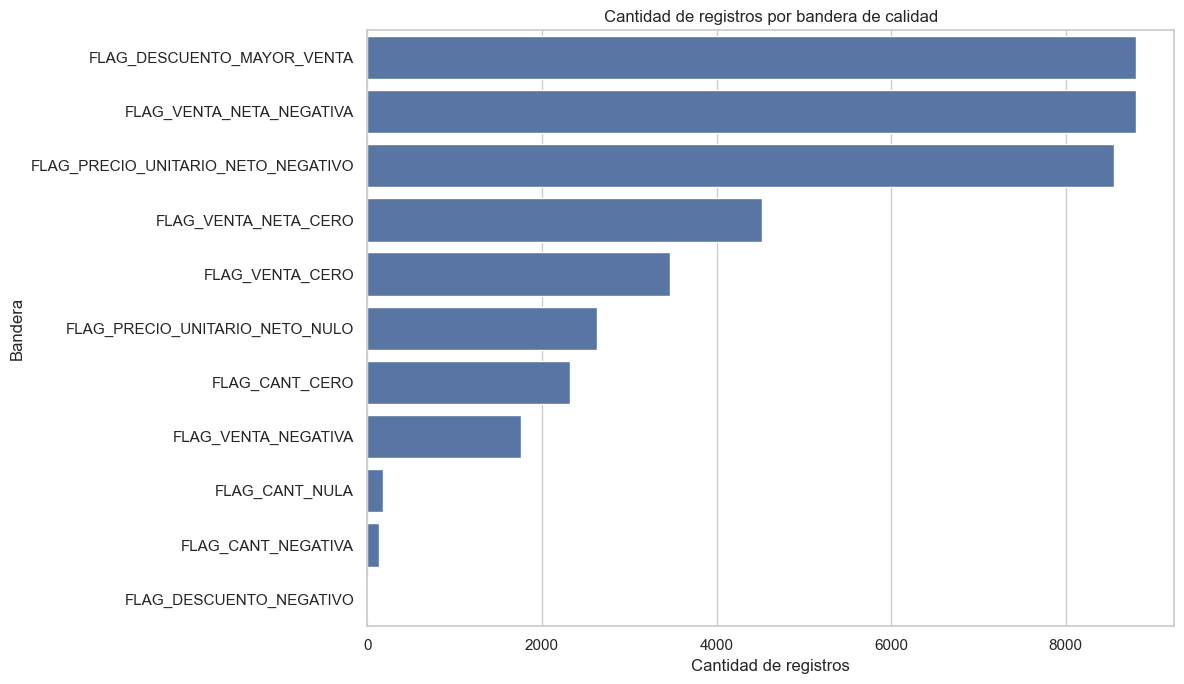

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\calidad_datos\banderas_calidad.png


In [20]:
# ===============================
# Gráfico de banderas de calidad
# ===============================

resumen_flags_plot = resumen_flags[resumen_flags["cantidad"] > 0].copy()

plt.figure(figsize=(12, 7))
sns.barplot(
    data=resumen_flags_plot,
    y="bandera",
    x="cantidad"
)
plt.title("Cantidad de registros por bandera de calidad")
plt.xlabel("Cantidad de registros")
plt.ylabel("Bandera")
plt.tight_layout()

output_fig = FIGURES_DIR / "calidad_datos" / "banderas_calidad.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

In [21]:
# ===============================
# Estadísticos descriptivos
# ===============================

cols_numericas = [
    "CANT",
    "VENTA",
    "DESCUENTO",
    "VENTA_NETA",
    "DESCUENTO_PCT",
    "PRECIO_UNITARIO_BRUTO",
    "PRECIO_UNITARIO_NETO"
]

estadisticos_limpios = df[cols_numericas].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).T

estadisticos_limpios

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
CANT,"409,580.00",1.21,3.51,-24.00,0.02,0.10,1.00,1.00,1.00,2.00,5.00,800.00
VENTA,"409,760.00",340.35,807.68,"-32,896.00",0.00,21.00,83.00,178.00,398.00,"1,116.00","2,289.00","195,457.00"
DESCUENTO,"409,760.00",39.71,269.24,-862.00,0.00,0.00,0.00,0.00,8.00,228.00,574.00,"80,080.00"
VENTA_NETA,"409,760.00",300.65,754.94,"-43,460.00",-168.00,11.00,75.00,164.00,342.00,"1,018.00","2,137.41","195,457.00"
DESCUENTO_PCT,"404,527.00",11.72,54.71,0.00,0.00,0.00,0.00,0.00,10.00,53.75,150.00,"18,800.00"
PRECIO_UNITARIO_BRUTO,"407,125.00",339.60,"1,110.82","-18,810.00",3.00,30.00,101.00,193.00,439.00,"1,110.00","1,771.00","376,900.00"
PRECIO_UNITARIO_NETO,"407,125.00",301.02,936.38,"-37,810.00",-166.00,19.50,88.00,180.00,385.00,"1,004.87","1,741.00","310,400.00"


In [22]:
# ===============================
# Resumen general limpio
# ===============================

resumen_general_limpio = pd.DataFrame({
    "metrica": [
        "Filas totales",
        "Columnas totales",
        "Fecha mínima",
        "Fecha máxima",
        "Días únicos",
        "PDV únicos",
        "Estratos únicos",
        "Categorías únicas",
        "Grupos comerciales únicos",
        "Productos únicos",
        "Facturas únicas globales",
        "Tickets únicos",
        "Venta bruta total",
        "Descuento total",
        "Venta neta total",
        "Unidades totales",
        "Líneas promocionales",
        "Porcentaje líneas promocionales",
        "Registros especiales",
        "Porcentaje registros especiales",
        "Registros válidos básicos",
        "Porcentaje registros válidos básicos"
    ],
    "valor": [
        len(df),
        df.shape[1],
        df["FECHA"].min(),
        df["FECHA"].max(),
        df["FECHA"].nunique(),
        df["PDV"].nunique(),
        df["Estrato"].nunique(),
        df["CATEG"].nunique(),
        df["GRUCOM"].nunique(),
        df["PLU_SAP"].nunique(),
        df["FACTURA"].nunique(),
        df["TICKET_ID"].nunique(),
        df["VENTA"].sum(),
        df["DESCUENTO"].sum(),
        df["VENTA_NETA"].sum(),
        df["CANT"].sum(),
        df["PROMO_FLAG"].sum(),
        df["PROMO_FLAG"].mean() * 100,
        df["REGISTRO_ESPECIAL"].sum(),
        df["REGISTRO_ESPECIAL"].mean() * 100,
        df["REGISTRO_VALIDO_BASICO"].sum(),
        df["REGISTRO_VALIDO_BASICO"].mean() * 100
    ]
})

resumen_general_limpio

,metrica,valor
0,Filas totales,409760
1,Columnas totales,54
2,Fecha mínima,2023-01-01 00:00:00
3,Fecha máxima,2024-12-31 00:00:00
4,Días únicos,731
5,PDV únicos,3
6,Estratos únicos,2
7,Categorías únicas,7
8,Grupos comerciales únicos,2
9,Productos únicos,6039


In [23]:
# ===============================
# Cobertura temporal
# ===============================

fecha_min = df["FECHA"].min()
fecha_max = df["FECHA"].max()

rango_fechas = pd.date_range(fecha_min, fecha_max, freq="D")
fechas_observadas = pd.Series(df["FECHA"].dropna().unique())

fechas_faltantes = sorted(set(rango_fechas) - set(fechas_observadas))

resumen_cobertura_temporal = pd.DataFrame({
    "metrica": [
        "Fecha mínima",
        "Fecha máxima",
        "Días esperados",
        "Días observados",
        "Días faltantes"
    ],
    "valor": [
        fecha_min,
        fecha_max,
        len(rango_fechas),
        df["FECHA"].nunique(),
        len(fechas_faltantes)
    ]
})

resumen_cobertura_temporal

,metrica,valor
0,Fecha mínima,2023-01-01 00:00:00
1,Fecha máxima,2024-12-31 00:00:00
2,Días esperados,731
3,Días observados,731
4,Días faltantes,0


In [24]:
# ===============================
# Fechas faltantes, si existen
# ===============================

if len(fechas_faltantes) > 0:
    fechas_faltantes_df = pd.DataFrame({"fecha_faltante": fechas_faltantes})
    display(fechas_faltantes_df.head(30))
else:
    fechas_faltantes_df = pd.DataFrame(columns=["fecha_faltante"])
    print("No se encontraron fechas faltantes en el periodo analizado.")

No se encontraron fechas faltantes en el periodo analizado.


In [25]:
# ===============================
# Calidad por PDV
# ===============================

calidad_pdv = (
    df.groupby("PDV")
    .agg(
        filas=("NroReg", "count"),
        registros_especiales=("REGISTRO_ESPECIAL", "sum"),
        registros_validos_basicos=("REGISTRO_VALIDO_BASICO", "sum"),
        cant_nula=("FLAG_CANT_NULA", "sum"),
        cant_cero=("FLAG_CANT_CERO", "sum"),
        cant_negativa=("FLAG_CANT_NEGATIVA", "sum"),
        venta_cero=("FLAG_VENTA_CERO", "sum"),
        venta_negativa=("FLAG_VENTA_NEGATIVA", "sum"),
        descuento_mayor_venta=("FLAG_DESCUENTO_MAYOR_VENTA", "sum"),
        venta_neta_negativa=("FLAG_VENTA_NETA_NEGATIVA", "sum")
    )
    .reset_index()
)

calidad_pdv["registros_especiales_pct"] = (
    calidad_pdv["registros_especiales"] / calidad_pdv["filas"] * 100
).round(2)

calidad_pdv["registros_validos_basicos_pct"] = (
    calidad_pdv["registros_validos_basicos"] / calidad_pdv["filas"] * 100
).round(2)

calidad_pdv

,PDV,filas,registros_especiales,registros_validos_basicos,cant_nula,cant_cero,cant_negativa,venta_cero,venta_negativa,descuento_mayor_venta,venta_neta_negativa,registros_especiales_pct,registros_validos_basicos_pct
0,1255,132627,4191,129092,82,767,63,1149,505,2688,2688,3.16,97.33
1,1311,201432,6028,196513,68,982,55,1353,622,3902,3902,2.99,97.56
2,980,75701,3278,72932,30,573,15,968,636,2209,2209,4.33,96.34


In [26]:
# ===============================
# Calidad por categoría
# ===============================

calidad_categoria = (
    df.groupby(["GRUCOM", "CATEG"])
    .agg(
        filas=("NroReg", "count"),
        registros_especiales=("REGISTRO_ESPECIAL", "sum"),
        registros_validos_basicos=("REGISTRO_VALIDO_BASICO", "sum"),
        cant_nula=("FLAG_CANT_NULA", "sum"),
        cant_cero=("FLAG_CANT_CERO", "sum"),
        cant_negativa=("FLAG_CANT_NEGATIVA", "sum"),
        venta_cero=("FLAG_VENTA_CERO", "sum"),
        venta_negativa=("FLAG_VENTA_NEGATIVA", "sum"),
        descuento_mayor_venta=("FLAG_DESCUENTO_MAYOR_VENTA", "sum"),
        venta_neta_negativa=("FLAG_VENTA_NETA_NEGATIVA", "sum")
    )
    .reset_index()
)

calidad_categoria["registros_especiales_pct"] = (
    calidad_categoria["registros_especiales"] / calidad_categoria["filas"] * 100
).round(2)

calidad_categoria["registros_validos_basicos_pct"] = (
    calidad_categoria["registros_validos_basicos"] / calidad_categoria["filas"] * 100
).round(2)

calidad_categoria.sort_values("registros_especiales", ascending=False)

,GRUCOM,CATEG,filas,registros_especiales,registros_validos_basicos,cant_nula,cant_cero,cant_negativa,venta_cero,venta_negativa,descuento_mayor_venta,venta_neta_negativa,registros_especiales_pct,registros_validos_basicos_pct
0,10,04010,158659,9111,151519,0,1213,11,2222,1254,5988,5988,5.74,95.50
2,11,08029,132505,2167,130491,73,622,38,693,271,1325,1325,1.64,98.48
3,11,08042,52788,902,52005,21,191,20,234,73,576,576,1.71,98.52
4,11,08061,53538,741,52806,25,195,20,210,69,515,515,1.38,98.63
5,11,08062,10997,528,10491,61,94,4,104,56,354,354,4.80,95.40
6,11,08067,876,47,829,0,6,40,6,40,41,41,5.37,94.63
1,10,04019,397,1,396,0,1,0,1,0,0,0,0.25,99.75


In [27]:
# ===============================
# Muestra de registros especiales
# ===============================

cols_revision = [
    "NroReg",
    "FECHA",
    "PDV",
    "Estrato",
    "OFERTA_ID",
    "FACTURA",
    "CATEG",
    "PLU_SAP",
    "CANT",
    "VENTA",
    "DESCUENTO",
    "VENTA_NETA",
    "DESCUENTO_PCT",
    "PRECIO_UNITARIO_NETO",
    "PROMO_FLAG",
    "TIPO_PROMO",
    "REGISTRO_ESPECIAL",
    "REGISTRO_VALIDO_BASICO"
]

df[df["REGISTRO_ESPECIAL"]][cols_revision].head(30)

,NroReg,FECHA,PDV,Estrato,OFERTA_ID,FACTURA,CATEG,PLU_SAP,CANT,VENTA,DESCUENTO,VENTA_NETA,DESCUENTO_PCT,PRECIO_UNITARIO_NETO,PROMO_FLAG,TIPO_PROMO,REGISTRO_ESPECIAL,REGISTRO_VALIDO_BASICO
87,1782,2023-01-01,1255,4,163377,57,04010,1345338,1.00,71.00,71.00,0.00,100.00,0.00,True,Oferta y descuento,True,True
93,1903,2023-01-01,1255,4,163377,57,04010,1345337,1.00,71.00,71.00,0.00,100.00,0.00,True,Oferta y descuento,True,True
123,2448,2023-01-01,980,4,0,106,04010,1036245,0.00,0.00,0.00,0.00,NaN,NaN,False,Sin promoción,True,False
195,4362,2023-01-01,1255,4,0,152,08061,1008762,0.00,0.00,0.00,0.00,NaN,NaN,False,Sin promoción,True,False
366,8554,2023-01-02,1255,4,163446,288,08042,1341191,1.00,178.00,416.00,-238.00,233.71,-238.00,True,Oferta y descuento,True,False
401,9527,2023-01-02,980,4,0,313,04010,1342490,0.00,0.00,0.00,0.00,NaN,NaN,False,Sin promoción,True,False
524,13053,2023-01-02,1311,6,0,211,08029,1013410,0.00,0.00,0.00,0.00,NaN,NaN,False,Sin promoción,True,False
586,14729,2023-01-02,980,4,0,437,08029,1115190,-1.00,-438.00,0.00,-438.00,NaN,NaN,False,Sin promoción,True,False
601,15053,2023-01-02,1255,4,163446,447,08042,1341191,1.00,178.00,416.00,-238.00,233.71,-238.00,True,Oferta y descuento,True,False
656,16410,2023-01-02,1255,4,0,366,08061,1011233,0.00,0.00,0.00,0.00,NaN,NaN,False,Sin promoción,True,False


In [28]:
# ===============================
# Ventas netas negativas
# ===============================

ventas_netas_negativas = df[df["VENTA_NETA"] < 0].copy()

print(f"Filas con venta neta negativa: {len(ventas_netas_negativas):,}")
print(f"Porcentaje: {len(ventas_netas_negativas) / len(df) * 100:.4f}%")

ventas_netas_negativas[cols_revision].head(30)

Filas con venta neta negativa: 8,799
Porcentaje: 2.1474%


,NroReg,FECHA,PDV,Estrato,OFERTA_ID,FACTURA,CATEG,PLU_SAP,CANT,VENTA,DESCUENTO,VENTA_NETA,DESCUENTO_PCT,PRECIO_UNITARIO_NETO,PROMO_FLAG,TIPO_PROMO,REGISTRO_ESPECIAL,REGISTRO_VALIDO_BASICO
366,8554,2023-01-02,1255,4,163446,288,08042,1341191,1.00,178.00,416.00,-238.00,233.71,-238.00,True,Oferta y descuento,True,False
586,14729,2023-01-02,980,4,0,437,08029,1115190,-1.00,-438.00,0.00,-438.00,NaN,NaN,False,Sin promoción,True,False
601,15053,2023-01-02,1255,4,163446,447,08042,1341191,1.00,178.00,416.00,-238.00,233.71,-238.00,True,Oferta y descuento,True,False
2041,53861,2023-01-05,980,4,0,1510,04010,1334627,-1.00,-228.00,0.00,-228.00,NaN,NaN,False,Sin promoción,True,False
2181,57343,2023-01-06,980,4,163364,1596,04010,1153834,1.00,249.00,374.00,-125.00,150.20,-125.00,True,Oferta y descuento,True,False
2218,57837,2023-01-06,980,4,163484,1638,04010,1036252,1.00,0.00,120.00,-120.00,NaN,-120.00,True,Oferta y descuento,True,False
2220,57847,2023-01-06,980,4,163364,1640,04010,1129746,1.00,204.00,307.00,-103.00,150.49,-103.00,True,Oferta y descuento,True,False
2234,58044,2023-01-06,1311,6,163364,1654,04010,1249844,1.00,219.00,329.00,-110.00,150.23,-110.00,True,Oferta y descuento,True,False
2258,58631,2023-01-06,1255,4,163364,1676,04010,1023640,1.00,179.00,269.00,-90.00,150.28,-90.00,True,Oferta y descuento,True,False
2295,59480,2023-01-06,1255,4,163446,1599,08042,1341191,1.00,178.00,416.00,-238.00,233.71,-238.00,True,Oferta y descuento,True,False


In [29]:
# ===============================
# Cantidades negativas
# ===============================

cantidades_negativas = df[df["CANT"] < 0].copy()

print(f"Filas con cantidad negativa: {len(cantidades_negativas):,}")
print(f"Porcentaje: {len(cantidades_negativas) / len(df) * 100:.4f}%")

cantidades_negativas[cols_revision].head(30)

Filas con cantidad negativa: 133
Porcentaje: 0.0325%


,NroReg,FECHA,PDV,Estrato,OFERTA_ID,FACTURA,CATEG,PLU_SAP,CANT,VENTA,DESCUENTO,VENTA_NETA,DESCUENTO_PCT,PRECIO_UNITARIO_NETO,PROMO_FLAG,TIPO_PROMO,REGISTRO_ESPECIAL,REGISTRO_VALIDO_BASICO
586,14729,2023-01-02,980,4,0,437,08029,1115190,-1.00,-438.00,0.00,-438.00,NaN,NaN,False,Sin promoción,True,False
2041,53861,2023-01-05,980,4,0,1510,04010,1334627,-1.00,-228.00,0.00,-228.00,NaN,NaN,False,Sin promoción,True,False
3785,85867,2023-01-08,1255,4,0,2771,08061,1013114,-1.00,-41.00,0.00,-41.00,NaN,NaN,False,Sin promoción,True,False
4783,111453,2023-01-11,1311,6,163719,3478,08042,1194236,-1.00,-79.00,-14.00,-65.00,NaN,NaN,True,Solo oferta,True,False
4790,111740,2023-01-11,1311,6,163719,3478,08042,1189178,-1.00,-430.00,-76.00,-354.00,NaN,NaN,True,Solo oferta,True,False
4810,112288,2023-01-11,1311,6,163719,3478,08029,1013410,-1.00,-321.00,-57.00,-264.00,NaN,NaN,True,Solo oferta,True,False
4928,115521,2023-01-11,1311,6,163719,3599,08062,1350391,-3.00,"-4,885.00",-862.00,"-4,023.00",NaN,NaN,True,Solo oferta,True,False
5055,118721,2023-01-11,1311,6,163719,3478,08029,1227143,-1.00,-565.00,-100.00,-465.00,NaN,NaN,True,Solo oferta,True,False
5115,120373,2023-01-11,1311,6,163719,3478,08061,1008390,-1.00,-142.00,-26.00,-116.00,NaN,NaN,True,Solo oferta,True,False
5155,121415,2023-01-11,1311,6,163719,3478,08061,1292233,-1.00,-637.00,-113.00,-524.00,NaN,NaN,True,Solo oferta,True,False


In [30]:
# ===============================
# Descuentos mayores que la venta
# ===============================

descuento_mayor_venta = df[df["DESCUENTO"] > df["VENTA"]].copy()

print(f"Filas con descuento mayor que venta: {len(descuento_mayor_venta):,}")
print(f"Porcentaje: {len(descuento_mayor_venta) / len(df) * 100:.4f}%")

descuento_mayor_venta[cols_revision].head(30)

Filas con descuento mayor que venta: 8,799
Porcentaje: 2.1474%


,NroReg,FECHA,PDV,Estrato,OFERTA_ID,FACTURA,CATEG,PLU_SAP,CANT,VENTA,DESCUENTO,VENTA_NETA,DESCUENTO_PCT,PRECIO_UNITARIO_NETO,PROMO_FLAG,TIPO_PROMO,REGISTRO_ESPECIAL,REGISTRO_VALIDO_BASICO
366,8554,2023-01-02,1255,4,163446,288,08042,1341191,1.00,178.00,416.00,-238.00,233.71,-238.00,True,Oferta y descuento,True,False
586,14729,2023-01-02,980,4,0,437,08029,1115190,-1.00,-438.00,0.00,-438.00,NaN,NaN,False,Sin promoción,True,False
601,15053,2023-01-02,1255,4,163446,447,08042,1341191,1.00,178.00,416.00,-238.00,233.71,-238.00,True,Oferta y descuento,True,False
2041,53861,2023-01-05,980,4,0,1510,04010,1334627,-1.00,-228.00,0.00,-228.00,NaN,NaN,False,Sin promoción,True,False
2181,57343,2023-01-06,980,4,163364,1596,04010,1153834,1.00,249.00,374.00,-125.00,150.20,-125.00,True,Oferta y descuento,True,False
2218,57837,2023-01-06,980,4,163484,1638,04010,1036252,1.00,0.00,120.00,-120.00,NaN,-120.00,True,Oferta y descuento,True,False
2220,57847,2023-01-06,980,4,163364,1640,04010,1129746,1.00,204.00,307.00,-103.00,150.49,-103.00,True,Oferta y descuento,True,False
2234,58044,2023-01-06,1311,6,163364,1654,04010,1249844,1.00,219.00,329.00,-110.00,150.23,-110.00,True,Oferta y descuento,True,False
2258,58631,2023-01-06,1255,4,163364,1676,04010,1023640,1.00,179.00,269.00,-90.00,150.28,-90.00,True,Oferta y descuento,True,False
2295,59480,2023-01-06,1255,4,163446,1599,08042,1341191,1.00,178.00,416.00,-238.00,233.71,-238.00,True,Oferta y descuento,True,False


In [31]:
# ===============================
# Tipos finales
# ===============================

resumen_tipos_finales = pd.DataFrame({
    "columna": df.columns,
    "tipo_final": df.dtypes.astype(str).values,
    "nulos": df.isna().sum().values,
    "nulos_pct": (df.isna().mean().values * 100).round(4),
    "unicos": df.nunique(dropna=False).values
})

resumen_tipos_finales

,columna,tipo_final,nulos,nulos_pct,unicos
0,NroReg,int64,0,0.00,409760
1,FECHA,datetime64[s],0,0.00,731
2,PDV,string,0,0.00,3
3,Estrato,string,0,0.00,2
4,OFERTA_ID,string,0,0.00,3123
5,FACTURA,string,0,0.00,233889
6,CATEG,str,0,0.00,7
7,PLU_SAP,string,0,0.00,6039
8,CANT,float64,180,0.04,242
9,VENTA,float64,0,0.00,4083


In [32]:
# ===============================
# Exportar tablas de calidad
# ===============================

output_excel = TABLES_DIR / "02_limpieza_y_calidad_datos.xlsx"

with pd.ExcelWriter(output_excel, engine="openpyxl") as writer:
    resumen_inicial.to_excel(writer, sheet_name="resumen_inicial", index=False)
    resumen_tipos_finales.to_excel(writer, sheet_name="tipos_finales", index=False)
    resumen_nulos_limpio.to_excel(writer, sheet_name="nulos_limpio", index=False)
    resumen_flags.to_excel(writer, sheet_name="banderas_calidad", index=False)
    resumen_general_limpio.to_excel(writer, sheet_name="resumen_general", index=False)
    resumen_cobertura_temporal.to_excel(writer, sheet_name="cobertura_temporal", index=False)
    fechas_faltantes_df.to_excel(writer, sheet_name="fechas_faltantes", index=False)
    estadisticos_limpios.to_excel(writer, sheet_name="estadisticos", index=True)
    calidad_pdv.to_excel(writer, sheet_name="calidad_pdv", index=False)
    calidad_categoria.to_excel(writer, sheet_name="calidad_categoria", index=False)

print(f"Archivo Excel exportado correctamente en: {output_excel}")

Archivo Excel exportado correctamente en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\tables\02_limpieza_y_calidad_datos.xlsx


In [33]:
# ===============================
# Guardar base limpia
# ===============================

df.to_parquet(INTERIM_FILE, index=False)
df.to_parquet(PROCESSED_FILE, index=False)

print("Base limpia guardada correctamente.")

print(f"Archivo interim: {INTERIM_FILE}")
print(f"Archivo processed: {PROCESSED_FILE}")

print(f"\nFilas guardadas: {df.shape[0]:,}")
print(f"Columnas guardadas: {df.shape[1]:,}")

Base limpia guardada correctamente.
Archivo interim: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\data\interim\ventas_limpieza_inicial.parquet
Archivo processed: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\data\processed\ventas_eda.parquet

Filas guardadas: 409,760
Columnas guardadas: 54


In [34]:
# ===============================
# Validación de archivo guardado
# ===============================

df_validacion = pd.read_parquet(PROCESSED_FILE)

print("Archivo procesado leído correctamente.")
print(f"Filas: {df_validacion.shape[0]:,}")
print(f"Columnas: {df_validacion.shape[1]:,}")

df_validacion.head()

Archivo procesado leído correctamente.
Filas: 409,760
Columnas: 54


,NroReg,FECHA,PDV,Estrato,OFERTA_ID,FACTURA,CATEG,PLU_SAP,CANT,VENTA,DESCUENTO,GRUCOM,FECHA_ORIGINAL,OFERTA_ID_NUM,VENTA_NETA,DESCUENTO_PCT,PRECIO_UNITARIO_BRUTO,PRECIO_UNITARIO_NETO,PROMO_OFERTA_FLAG,PROMO_DESCUENTO_FLAG,PROMO_FLAG,TIPO_PROMO,ANIO,MES,DIA,DIA_SEMANA_NUM,DIA_SEMANA,SEMANA_ANIO,TRIMESTRE,FIN_SEMANA,FIN_MES,INICIO_MES,QUINCENA,MES_NOMBRE,DIA_SEMANA_NOMBRE,TICKET_ID,FLAG_FECHA_NULA,FLAG_CANT_NULA,FLAG_CANT_CERO,FLAG_CANT_NEGATIVA,FLAG_VENTA_NULA,FLAG_VENTA_CERO,FLAG_VENTA_NEGATIVA,FLAG_DESCUENTO_NULO,FLAG_DESCUENTO_CERO,FLAG_DESCUENTO_NEGATIVO,FLAG_DESCUENTO_MAYOR_VENTA,FLAG_VENTA_NETA_NULA,FLAG_VENTA_NETA_CERO,FLAG_VENTA_NETA_NEGATIVA,FLAG_PRECIO_UNITARIO_NETO_NULO,FLAG_PRECIO_UNITARIO_NETO_NEGATIVO,REGISTRO_ESPECIAL,REGISTRO_VALIDO_BASICO
0,4,2023-01-01,980,4,0,1,04010,1280454,3.00,298.00,0.00,10,44927,0,298.00,0.00,99.33,99.33,False,False,False,Sin promoción,2023,1,1,6,Sunday,52,1,True,False,True,1,Enero,Domingo,2023-01-01_980_1,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True
1,12,2023-01-01,1255,4,0,2,04010,1328730,1.00,115.00,0.00,10,44927,0,115.00,0.00,115.00,115.00,False,False,False,Sin promoción,2023,1,1,6,Sunday,52,1,True,False,True,1,Enero,Domingo,2023-01-01_1255_2,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True
2,24,2023-01-01,1255,4,0,3,04010,1036266,3.00,448.00,0.00,10,44927,0,448.00,0.00,149.33,149.33,False,False,False,Sin promoción,2023,1,1,6,Sunday,52,1,True,False,True,1,Enero,Domingo,2023-01-01_1255_3,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True
3,36,2023-01-01,1311,6,0,4,08061,1265857,1.00,82.00,0.00,11,44927,0,82.00,0.00,82.00,82.00,False,False,False,Sin promoción,2023,1,1,6,Sunday,52,1,True,False,True,1,Enero,Domingo,2023-01-01_1311_4,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True
4,37,2023-01-01,980,4,0,5,04010,1328946,4.00,519.00,0.00,10,44927,0,519.00,0.00,129.75,129.75,False,False,False,Sin promoción,2023,1,1,6,Sunday,52,1,True,False,True,1,Enero,Domingo,2023-01-01_980_5,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True


## Conclusiones de limpieza y calidad de datos

Después del proceso de limpieza inicial, la base quedó preparada para el EDA completo.

Las principales transformaciones realizadas fueron:

1. La variable `FECHA` fue convertida desde serial de Excel a formato fecha real.

2. Las variables `CANT`, `VENTA` y `DESCUENTO` fueron convertidas a formato numérico para permitir cálculos y análisis estadísticos.

3. Se creó la variable `VENTA_NETA`, definida como:

   `VENTA_NETA = VENTA - DESCUENTO`

4. Se crearon variables de precio unitario, porcentaje de descuento y promoción.

5. Se construyeron variables temporales como año, mes, día, semana del año, día de la semana, trimestre, fin de semana, fin de mes y quincena.

6. Se creó el identificador `TICKET_ID`, combinando fecha, PDV y factura, debido a que la factura por sí sola no necesariamente identifica de forma única una compra.

7. Se crearon banderas de calidad para detectar casos especiales como cantidades negativas, ventas negativas, descuentos mayores que la venta y ventas netas negativas.

8. No se eliminaron registros en esta etapa. Los registros especiales quedaron marcados para ser analizados con más detalle en notebooks posteriores.

9. La base limpia fue guardada en:

   `data/processed/ventas_eda.parquet`

